In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, MaxPool1D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, precision_recall_curve
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from sklearn.utils import shuffle
import keras
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.utils import to_categorical
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc



from keras.layers import Dense, LSTM, MaxPool1D, Flatten, Dropout # importing dense layer
from keras.models import Sequential #importing Sequential layer
from keras.layers import Input
from keras.models import Model
# representation of model layers


import pickle # saving and loading trained model
from os import path

# importing required libraries for normalizing data
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

# importing library for plotting
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from keras.layers import Dense, LSTM, MaxPool1D, Flatten, Dropout # importing dense layer
from keras.models import Sequential #importing Sequential layer
from keras.layers import Input
from keras.models import Model
# representation of model layers

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.models import Model
from keras.layers import LSTM, Activation, Dense, Dropout, Input, Embedding
from keras.optimizers import RMSprop

from keras.preprocessing import sequence
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping
%matplotlib inline
from sklearn.preprocessing import LabelEncoder

from keras.utils import to_categorical
from keras.optimizers import RMSprop
from keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import classification_report,roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

%matplotlib inline

from sklearn.preprocessing import LabelEncoder

from keras.utils import to_categorical
from keras.optimizers import RMSprop
from keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import classification_report,roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split


In [66]:
df=pd.read_csv('C:\\Users\\sobha\\Downloads\\Phishing_Email.csv\\Phishing_Email.csv',delimiter=',',encoding='latin-1')

In [67]:
df.head()

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [68]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [69]:
df.head()

,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Email Text  18634 non-null  object
 1   Email Type  18650 non-null  object
dtypes: object(2)
memory usage: 291.5+ KB


In [71]:
df.describe().T

,count,unique,top,freq
Email Text,18634,17537,empty,533
Email Type,18650,2,Safe Email,11322


In [72]:
print(df.isna().sum())
print(df.duplicated().sum())

Email Text    16
Email Type     0
dtype: int64
1111


In [73]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [74]:
print(df.isna().sum())
print(df.duplicated().sum())

Email Text    0
Email Type    0
dtype: int64
0


Text(0.5, 1.0, 'Number of Phishing email and Safe email messages')

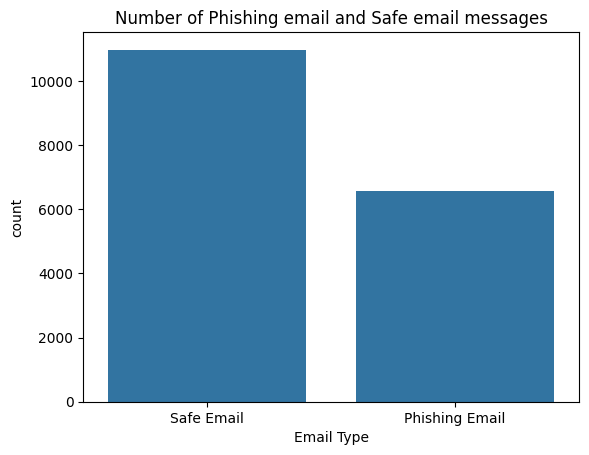

In [75]:
sns.countplot(data=df, x='Email Type')
plt.xlabel('Email Type')
plt.title('Number of Phishing email and Safe email messages')


In [76]:
x = df['Email Text']
y = df['Email Type']

le = LabelEncoder()

y = le.fit_transform(y)
y = y.reshape(-1,1)

In [77]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 10)

In [83]:
import keras
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.preprocessing import Tokenizer
max_words = 10000
max_len = 150

tok = Tokenizer(num_words=max_words)
#Process the train set data
tok.fit_on_texts(x_train)
sequences = tok.texts_to_sequences(x_train)
sequences_matrix = pad_sequences(sequences, maxlen=max_len)

#Process the test set data.
test_sequences = tok.texts_to_sequences(x_test)
test_sequences_matrix = pad_sequences(test_sequences,maxlen=max_len)

ImportError: cannot import name 'Tokenizer' from 'keras.preprocessing' (c:\Users\sobha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\api\preprocessing\__init__.py)

In [ ]:
sequences_matrix

In [ ]:
sequences_matrix.shape

In [ ]:
from keras.models import Sequential
from keras.layers import  Dense,Embedding

model = Sequential()
model.add(Embedding(10000,32))
model.add(LSTM(32, activation='sigmoid' ))
model.add(Dense(1, activation='sigmoid'))
# # model.add(CuDNNLSTM(128, return_sequences=True)) 
# # model.add(CuDNNLSTM(128))
# model = Sequential()
# model.add(Dense(32,activation="relu"))
# model.add(Dropout(0.3))

# model.add(Dense(32,activation="relu"))
# model.add(Dropout(0.3))
# model.add(Dense(1, kernel_initializer='uniform', activation='sigmoid'))
# # model.add(Dense(1,activation='sigmoid'))


In [ ]:
model.compile(loss=['binary_crossentropy'] , optimizer='adam', metrics=['accuracy',tf.keras.metrics.Precision(),tf.keras.metrics.Recall()])

In [ ]:
model.summary()

In [ ]:
history = model.fit(sequences_matrix, y_train, epochs=30, batch_size=128, validation_data=(test_sequences_matrix, y_test))

In [ ]:
results = model.evaluate(test_sequences_matrix, y_test)
loss = results[0]  # Extract the loss from the results
accuracy = results[1]  # Extract the accuracy from the results

print(f"Model Loss: {loss}")
print(f"Model Accuracy: {accuracy*100}")

In [ ]:
pd.DataFrame(history.history)

pd.DataFrame(history.history)[['accuracy', 'val_accuracy']].plot()
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')

pd.DataFrame(history.history)[['loss', 'val_loss']].plot()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

In [ ]:
y_pred_prob = model.predict(test_sequences_matrix)
y_pred = (y_pred_prob > 0.5).astype(int)

In [ ]:
report = classification_report(y_true=y_test, y_pred=y_pred)
print(report)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# create a ConfusionMatrixDisplay object
cm_display = ConfusionMatrixDisplay(cm)

# plot the confusion matrix
print("Confusion Matrix:\n", cm)
cm_display.plot()
plt.show()

In [ ]:
import numpy as np


def plot_confusion_matrix(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=True):

    import matplotlib.pyplot as plt
    import numpy as np
    import itertools

    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")


    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label\naccuracy={:0.4f}; misclass={:0.4f}'.format(accuracy, misclass))
    plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
plot_confusion_matrix(cm=confusion_matrix(y_test, y_pred),
                      normalize=False,
                      target_names=[],
                      title="Confusion Matrix")

In [ ]:
from sklearn.metrics import confusion_matrix
plot_confusion_matrix(cm=confusion_matrix(y_test, y_pred),
                      normalize=True,
                      target_names=[],
                      title="Confusion Matrix")

In [ ]:
# fpr, tpr, _ = roc_curve(y_test,  y_pred_prob)
# auc = roc_auc_score(y_test, y_pred_prob)

# #create ROC curve
# plt.plot(fpr,tpr,label="AUC="+str(auc))
# plt.ylabel('True Positive Rate')
# plt.xlabel('False Positive Rate')
# plt.legend(loc=4)
# plt.show()

In [ ]:
from sklearn.metrics import auc



fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()
print("AUC Score:", roc_auc)

In [ ]:
model.save("LSTM Phishing Email.h5")